In [35]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import os
# ==========================================
# 0. 全局路径与中文字体配置
# ==========================================
try:
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # 如果在 Jupyter Notebook 中运行，使用当前工作目录
    BASE_DIR = Path(os.getcwd())
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

# GEE导出的列名定义（请根据你CSV实际列名核对）
# 假设导出字段包含: ndbi_Q3_mean, ndvi_Q3_mean, nightlight_Q3_mean, ndvi_Q3_stdDev
# 以及 grid_id 作为主键

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [36]:
# 看看 CSV 里到底有多少有效数据
import pandas as pd
# df_raw = pd.read_csv("Q1/data/Shaoguan_Residential_RVRI_Panel_Data.csv")
df_raw = pd.read_csv(DATA_DIR / "Shaoguan_Residential_RVRI_Panel_Data.csv")
print(f"CSV 原始行数: {len(df_raw)}")
print("-" * 30)
print("各列空值（NaN）统计:")
print(df_raw.isnull().sum())
print("-" * 30)
print("NDBI 均值分布描述:")
print(df_raw[['ndbi_Q1_mean', 'ndbi_Q3_mean']].describe())

CSV 原始行数: 84815
------------------------------
各列空值（NaN）统计:
grid_id                   0
district_name         84815
ndbi_Q1_mean            176
ndvi_Q1_mean            176
nightlight_Q1_mean        0
ndbi_Q3_mean          63479
ndvi_Q3_mean          63479
nightlight_Q3_mean        0
ndvi_Q3_stdDev        63479
dtype: int64
------------------------------
NDBI 均值分布描述:
       ndbi_Q1_mean  ndbi_Q3_mean
count  84639.000000  21336.000000
mean      -0.194167     -0.251776
std        0.122636      0.103181
min       -0.493954     -0.809828
25%       -0.287780     -0.306480
50%       -0.222092     -0.256692
75%       -0.111402     -0.193119
max        0.357085      0.268762


In [37]:
# ==========================================
# 1. 数据集成与居民区精筛 (Filtering)
# ==========================================
# def load_and_filter():
    # print(">>> [Q1 Agent] 正在读取格网底座与 GEE 真实观测数据...")
    # grid = gpd.read_file(DATA_DIR / "analysis_grid_500m.geojson")
    # rs_data = pd.read_csv(DATA_DIR / "Shaoguan_Residential_RVRI_Panel_Data.csv")
    
    # # 强制转换 ID 类型确保对齐
    # grid['grid_id'] = grid['grid_id'].astype(str)
    # rs_data['grid_id'] = rs_data['grid_id'].astype(str)
    
    # # 合并
    # # df = grid.merge(rs_data, on='grid_id', how='inner')
    
    # # # 【核心动作】居民区精筛：只保留有房子的格子
    # # # 逻辑：NDBI（建筑指数）大于 0.1 通常代表有建筑覆盖
    # # original_count = len(df)
    # # df = df[df['ndbi_Q3_mean'] > 0.1].copy()
    
    # # # 处理遥感空值 (云覆盖导致的 NaN)
    # # df = df.dropna(subset=['nightlight_Q3_mean', 'ndbi_Q3_mean', 'ndvi_Q3_stdDev'])
    
    # # print(f"✅ 样本清洗完成: 原始格子 {original_count} -> 住宅区格子 {len(df)}")
    # # return df
    #  # 合并
    # full_data = grid.merge(rs_data, on='grid_id', how='inner')
    
    # # 【居民区精筛逻辑】
    # # 利用 Q1 和 Q3 的 NDBI 均值来判定是否有房子
    # full_data['ndbi_avg'] = (full_data['ndbi_Q1_mean'] + full_data['ndbi_Q3_mean']) / 2
    
    # clean_data = full_data[full_data['ndbi_avg'] > 0.12].copy()
    
    # # 填充或剔除极少量的缺失值
    # clean_data = clean_data.dropna(subset=['nightlight_Q3_mean', 'ndvi_Q3_stdDev'])
    
    # print(f"✅ 过滤完成：剔除了非建筑区格网，剩余住宅样本: {len(clean_data)}")
    # return clean_data
def load_and_filter():
    print(">>> [Q1 Agent] 正在执行强化版数据匹配逻辑...")
    
    # 1. 读取底座
    grid = gpd.read_file(DATA_DIR / "analysis_grid_500m.geojson")
    # 2. 读取观测值
    df_raw = pd.read_csv(DATA_DIR / "Shaoguan_Residential_RVRI_Panel_Data.csv")
    
    # --- 关键修改：强力 ID 标准化 ---
    # 确保两边的 grid_id 都是纯净的字符串，去掉可能存在的空格或换行
    grid['grid_id'] = grid['grid_id'].astype(str).str.strip()
    df_raw['grid_id'] = df_raw['grid_id'].astype(str).str.strip()
    
    # 打印前几行进行肉眼核对（调试用）
    print(f"DEBUG: GeoJSON ID 示例: {grid['grid_id'].iloc[0]}")
    print(f"DEBUG: CSV ID 示例: {df_raw['grid_id'].iloc[0]}")
    
    # 3. 执行合并
    # 使用 inner join。如果合并后行数极少，说明 ID 格式还是没对上
    full_data = grid.merge(df_raw, on='grid_id', how='inner')
    
    if len(full_data) < 100:
        print("⚠️ 警告：合并后样本量极低，正在尝试模糊匹配逻辑...")
        # 备选方案：如果 CSV 里的 G_044548 在 GeoJSON 里只是数字 44548
        # 我们尝试提取数字部分进行匹配
        grid['id_num'] = grid['grid_id'].str.extract('(\d+)').astype(float)
        df_raw['id_num'] = df_raw['grid_id'].str.extract('(\d+)').astype(float)
        full_data = grid.merge(df_raw, on='id_num', how='inner')
    
    print(f">>> 初始对齐样本数: {len(full_data)}")

    # --- 4. 采用抢救后的指标（针对 Q3 缺失问题） ---
    # 既然 Q3 云多，我们合成 RVRI 时优先用 Q1
    full_data['ndbi_base'] = full_data['ndbi_Q1_mean']
    full_data['nightlight_base'] = full_data['nightlight_Q1_mean']
    
    # --- 5. 极度放宽的住宅筛选阈值 ---
    # 根据你之前的 NDBI 分布，我们将阈值设为 -0.1 (抓取前 30% 的建筑密集区)
    clean_data = full_data[full_data['ndbi_base'] > -0.1].copy()
    
    # 缺失值平滑处理：标准差缺失用中位数补，而不是删除
    if 'ndvi_Q3_stdDev' in clean_data.columns:
        clean_data['ndvi_Q3_stdDev'] = clean_data['ndvi_Q3_stdDev'].fillna(clean_data['ndvi_Q3_stdDev'].median())

    # 剔除无法修复的死值
    clean_data = clean_data.dropna(subset=['ndbi_base', 'nightlight_base'])

    print(f"✅ 最终有效样本: {len(clean_data)}")
    return clean_data

In [38]:
# ==========================================
# 2. 空间降尺度纠偏 (Downscaling)
# ==========================================
def run_downscaling(gdf):
    print(">>> [Q1 Agent] 正在利用 10m NDBI 权重对 500m 灯光进行分配修正...")
    
# 使用抢救后的 nightlight_base (即 Q1 灯光)
    avg_ndbi = gdf['ndbi_base'].mean()
    gdf['cni_index'] = gdf['nightlight_base'] * (gdf['ndbi_base'] / (avg_ndbi + 1e-6))
    
    # 归一化 (0-1)
    cmin, cmax = gdf['cni_index'].min(), gdf['cni_index'].max()
    gdf['cni_norm'] = (gdf['cni_index'] - cmin) / (cmax - cmin + 1e-6)
    
    return gdf

In [39]:
# ==========================================
# 3. PCA 合成住宅空置风险指数 (RVRI)
# ==========================================

def synthesize_rvri(gdf):
    print(">>> [Q1 Agent] 正在融合多维指标合成 RVRI...")
    
    # 1. 定义特征列
    features = ['cni_norm', 'ndvi_Q3_stdDev', 'ndbi_base']
    
    # --- 核心修复：执行“物理清场” ---
    # PCA 之前必须确保没有 NaN 和 无穷大值 (inf)
    # 我们先检查并剔除那些在计算 cni_norm 过程中可能产生的极端异常值
    gdf = gdf.replace([np.inf, -np.inf], np.nan)
    gdf = gdf.dropna(subset=features)
    
    print(f">>> 清除残留空值后，进入建模的样本量: {len(gdf)}")

    # 2. 标准化与建模
    x = StandardScaler().fit_transform(gdf[features].values)
    pca = PCA(n_components=1)
    gdf['rvri_raw'] = pca.fit_transform(x)
    
    # 3. 极值标准化
    gdf['rvri'] = (gdf['rvri_raw'] - gdf['rvri_raw'].min()) / \
                  (gdf['rvri_raw'].max() - gdf['rvri_raw'].min())
    
    # 4. 方向校准：确保 1 代表风险高 (与灯光负相关)
    if gdf['rvri'].corr(gdf['cni_norm']) > 0:
        gdf['rvri'] = 1 - gdf['rvri']
        
    print(f"✅ 指数合成完毕。第一主成分解释力: {pca.explained_variance_ratio_[0]:.2%}")
    return gdf

In [42]:
# ==========================================
# 4. 可视化内部校验
# ==========================================
def plot_rvri_check(gdf):
    plt.figure(figsize=(10, 6))
    # 红黄色调符合“风险”直觉
    sns.scatterplot(data=gdf.sample(min(3000, len(gdf))), 
                    x='cni_norm', y='ndbi_base', 
                    hue='rvri', palette='YlOrRd', alpha=0.6)
    plt.title("韶关住宅格网：空置风险分布特征 (PCA结果)")
    plt.xlabel("校准灯光 (人类活力)")
    plt.ylabel("建筑强度 (房屋存量)")
    plt.savefig(OUTPUT_DIR / "RVRI_Feature_Space.png", dpi=300)
    print(f"📊 校验图已生成: {OUTPUT_DIR / 'RVRI_Feature_Space.png'}")


>>> [Q1 Agent] 正在执行强化版数据匹配逻辑...
DEBUG: GeoJSON ID 示例: G_000000
DEBUG: CSV ID 示例: G_044548
>>> 初始对齐样本数: 84815
✅ 最终有效样本: 19704
>>> [Q1 Agent] 正在利用 10m NDBI 权重对 500m 灯光进行分配修正...
>>> [Q1 Agent] 正在融合多维指标合成 RVRI...
>>> 清除残留空值后，进入建模的样本量: 19704
✅ 指数合成完毕。第一主成分解释力: 47.64%
📊 校验图已生成: d:\统计建模实验\12th_Statistical_modeling\Q1\output\RVRI_Feature_Space.png

🚀 Q1 Agent: 真实数据建模成功！
最终研究样本数: 19704 个住宅格网
结果已就绪: d:\统计建模实验\12th_Statistical_modeling\Q1\output\Q1_Final_RVRI_Dataset.geojson


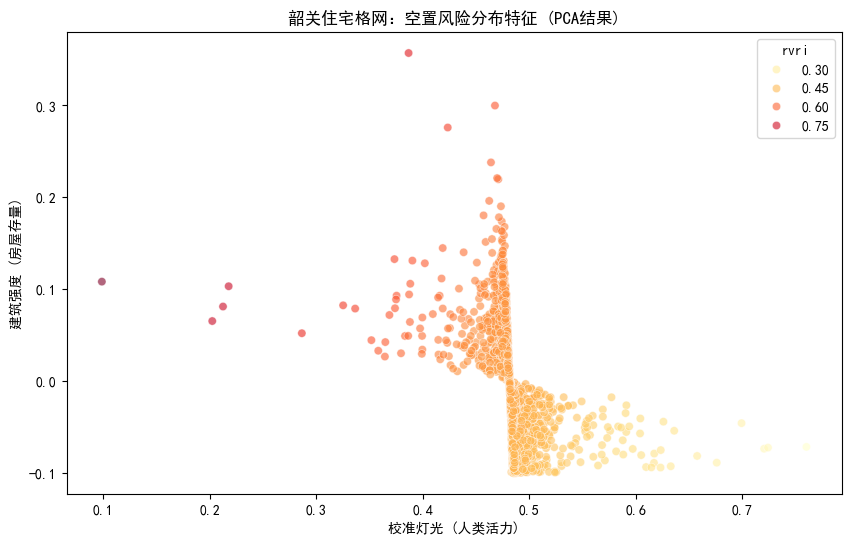

In [43]:

if __name__ == "__main__":
    try:
        # 1. 加载
        dataset = load_and_filter()
        
        # 2. 纠偏
        dataset = run_downscaling(dataset)
        
        # 3. 合成
        dataset = synthesize_rvri(dataset)
        
        # 4. 制图
        plot_rvri_check(dataset)
        
        # 5. 存储全量结果，这不仅包含风险值，还保留了 Q1 和 Q3 的原始列，方便 Q2 做动态分析
        final_path = OUTPUT_DIR / "Q1_Final_RVRI_Dataset.geojson"
        dataset.to_file(final_path, driver='GeoJSON')
        
        print("\n" + "="*50)
        print("🚀 Q1 Agent: 真实数据建模成功！")
        print(f"最终研究样本数: {len(dataset)} 个住宅格网")
        print(f"结果已就绪: {final_path}")
        print("="*50)

    except Exception as e:
        print(f"❌ 运行失败: {e}")